# Rabi result plots

Fresh notebook (the previous one was deleted after the background-artifact
investigation in notes.md was resolved -- see notes.md for the full
history of fixes leading up to the current `rabi.py`/`anchor_free_reps`/
`extra_settle_s` settings).

## Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "D:/rabi"
FILE_NAMES = ["measurement3", "measurement4", "measurement5", "measurement6", "measurement7", "measurement8"]

runs = {}
for file_name in FILE_NAMES:
    run_path = f"{DATA_DIR}/{file_name}"

    mw_us = np.load(f"{run_path}/{file_name}_rabi_mw_us.npy")
    x_v = np.load(f"{run_path}/{file_name}_rabi_x.npy")
    y_v = np.load(f"{run_path}/{file_name}_rabi_y.npy")
    reflected_dbm = np.load(f"{run_path}/{file_name}_rabi_reflected_dbm.npy")

    with open(f"{run_path}/{file_name}_rabi_metadata.txt") as fh:
        metadata_text = fh.read()
    metadata = dict(
        (k, float(v)) for k, v in
        (line.split("=", 1) for line in metadata_text.strip().splitlines())
    )

    runs[file_name] = dict(
        run_path=run_path, mw_us=mw_us, x_v=x_v, y_v=y_v,
        reflected_dbm=reflected_dbm, metadata=metadata,
    )

    print(f"{file_name}: {len(mw_us)} points, tau_mw {mw_us.min():.3f}-{mw_us.max():.3f} us")
    print(metadata_text)

measurement3: 41 points, tau_mw 0.020-2.020 us
freq_hz=2850000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

measurement4: 21 points, tau_mw 0.005-1.005 us
freq_hz=2850000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

measurement5: 100 points, tau_mw 0.005-0.995 us
freq_hz=2850000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

measurement6: 100 points, tau_mw 0.005-0.995 us
freq_hz=2850000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

measurement7: 26 points, tau_mw 0.005-5.005 us
freq_hz

## Rabi X/Y/R

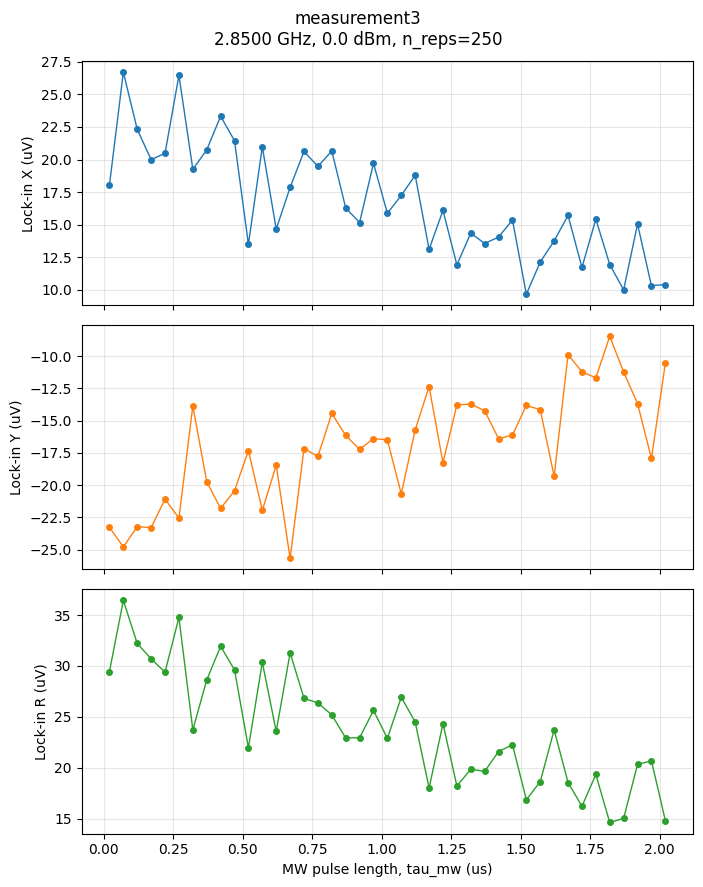

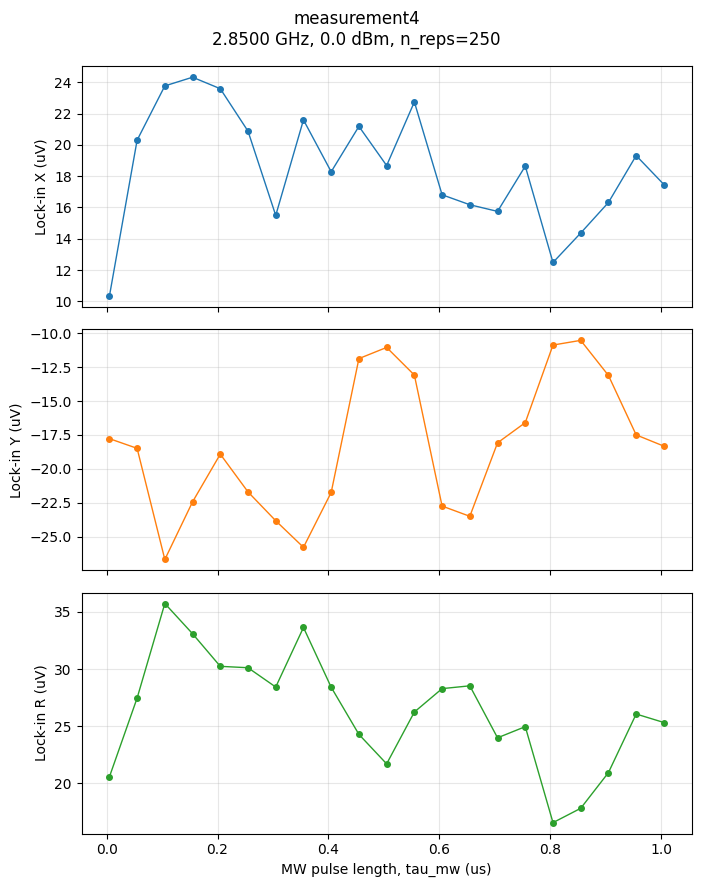

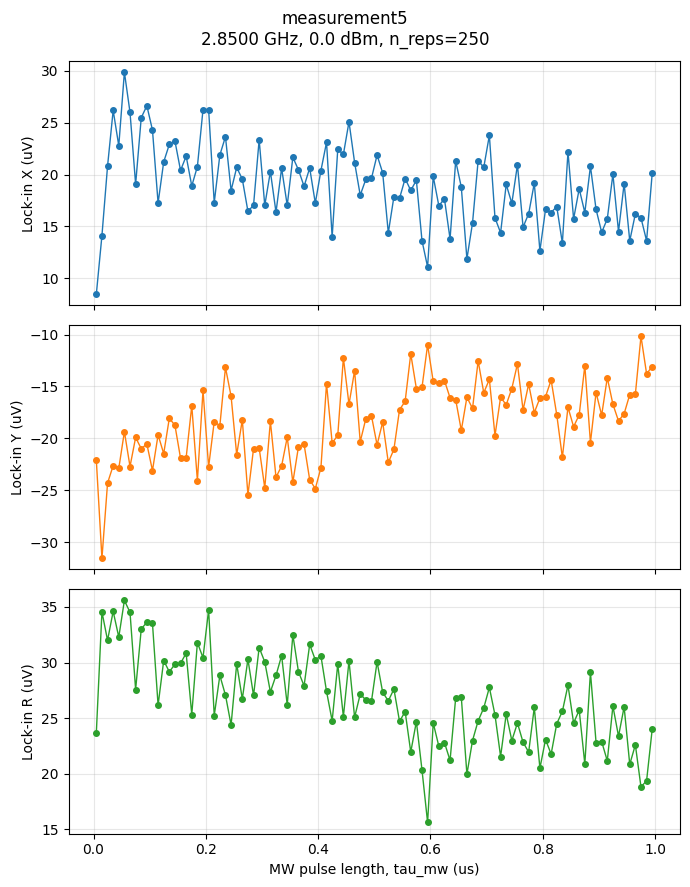

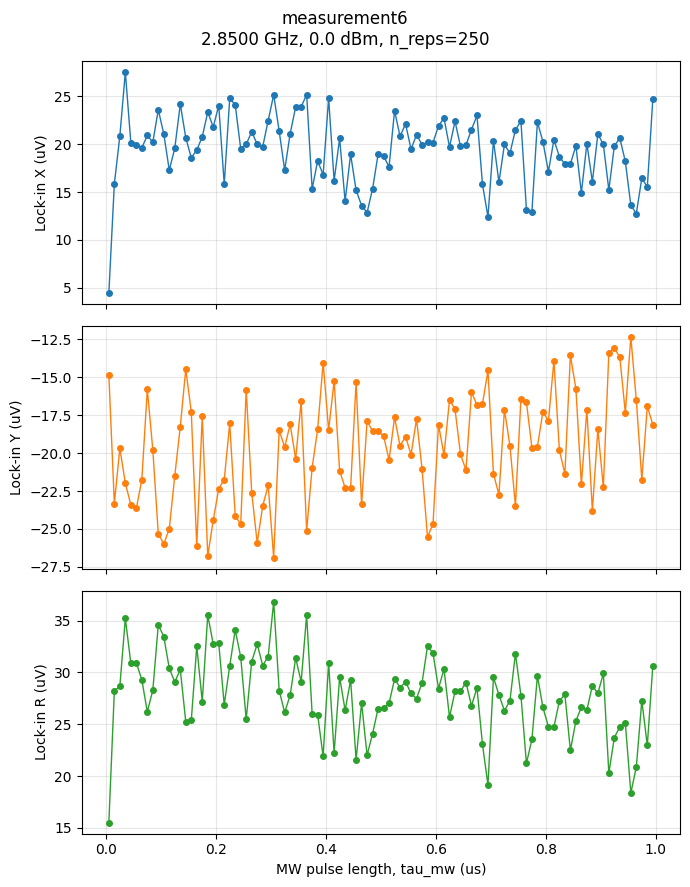

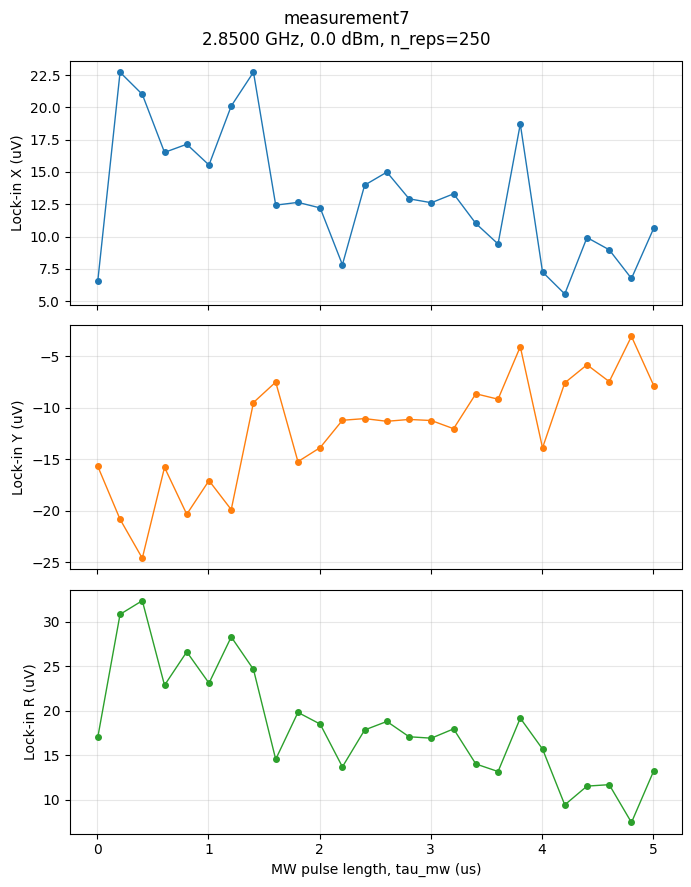

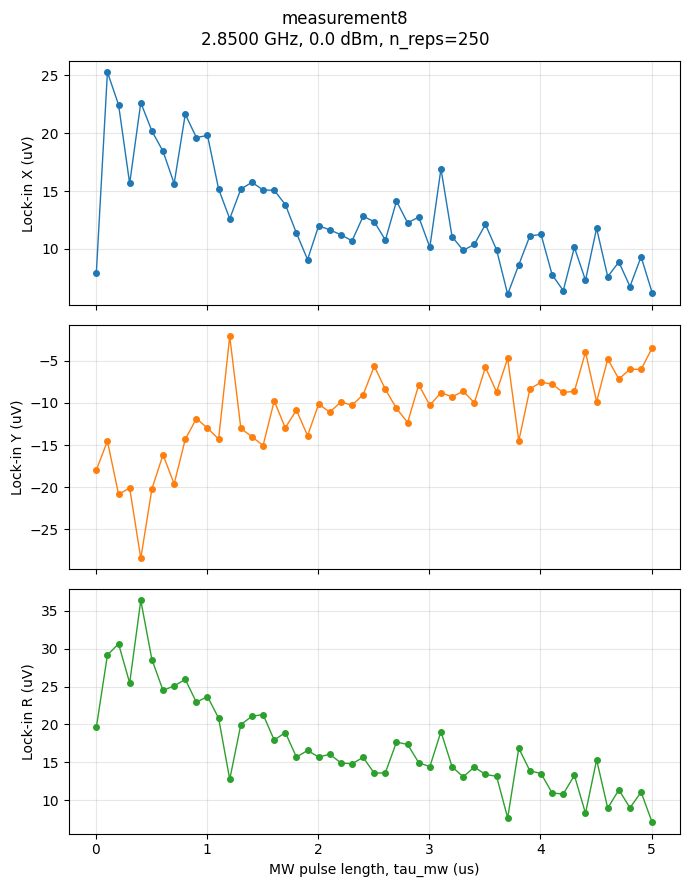

In [2]:
for file_name, d in runs.items():
    r_v = np.sqrt(d["x_v"]**2 + d["y_v"]**2)

    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
    axes[0].plot(d["mw_us"], d["x_v"] * 1e6, "o-", ms=4, lw=1, color="tab:blue")
    axes[1].plot(d["mw_us"], d["y_v"] * 1e6, "o-", ms=4, lw=1, color="tab:orange")
    axes[2].plot(d["mw_us"], r_v * 1e6, "o-", ms=4, lw=1, color="tab:green")

    freq_ghz = d["metadata"]["freq_hz"] / 1e9
    drive_dbm = d["metadata"]["drive_power_dbm"]
    n_reps = int(d["metadata"]["n_reps"])

    axes[0].set_ylabel("Lock-in X (uV)")
    axes[1].set_ylabel("Lock-in Y (uV)")
    axes[2].set_ylabel("Lock-in R (uV)")
    axes[2].set_xlabel("MW pulse length, tau_mw (us)")
    for ax in axes:
        ax.grid(alpha=0.3)

    fig.suptitle(f"{file_name}\n{freq_ghz:.4f} GHz, {drive_dbm:.1f} dBm, n_reps={n_reps}")
    plt.tight_layout()
    plt.show()

## Interlock reflected-power checks

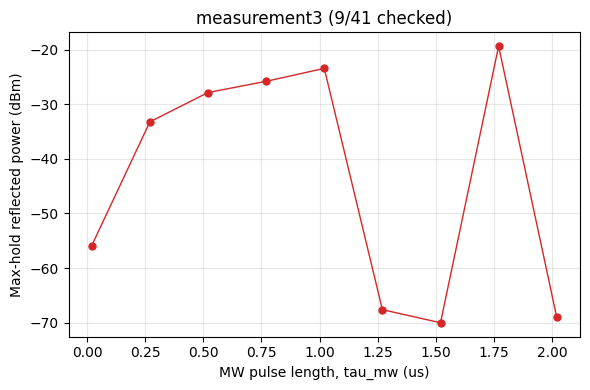

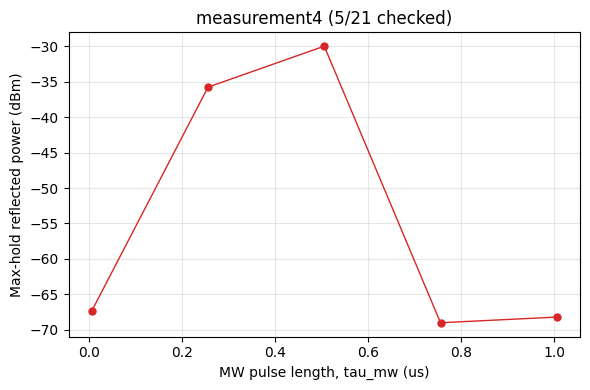

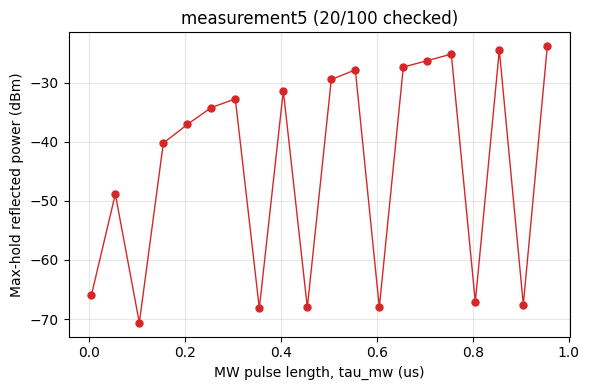

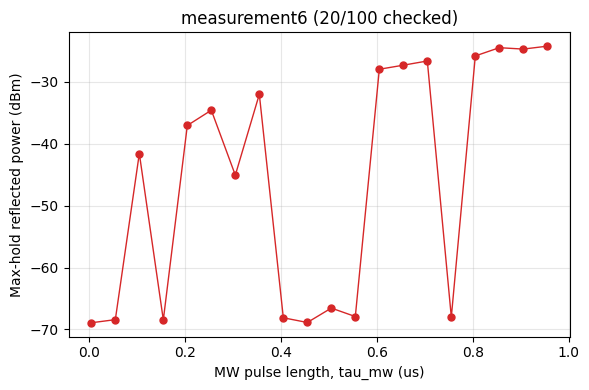

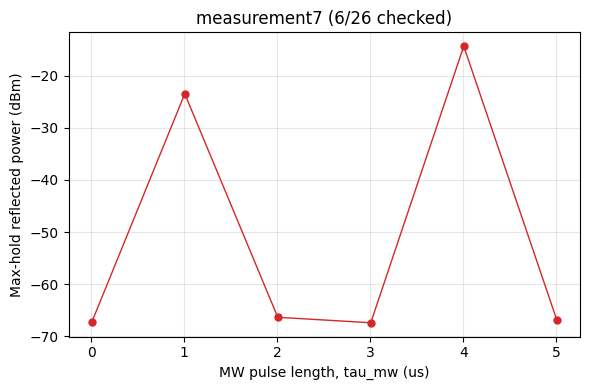

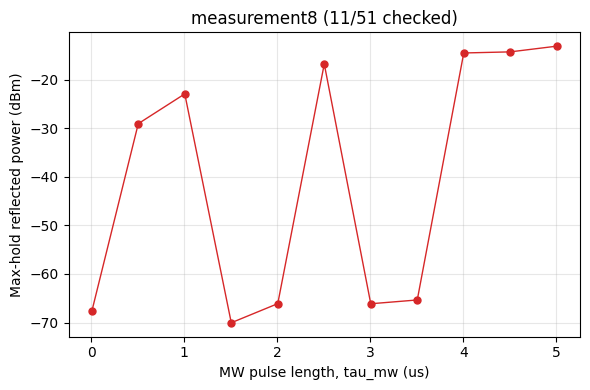

In [3]:
for file_name, d in runs.items():
    checked = ~np.isnan(d["reflected_dbm"])
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(d["mw_us"][checked], d["reflected_dbm"][checked], "o-", ms=5, lw=1, color="tab:red")
    ax.set_xlabel("MW pulse length, tau_mw (us)")
    ax.set_ylabel("Max-hold reflected power (dBm)")
    ax.set_title(f"{file_name} ({checked.sum()}/{len(d['mw_us'])} checked)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Pre-flight reflected-power sweep

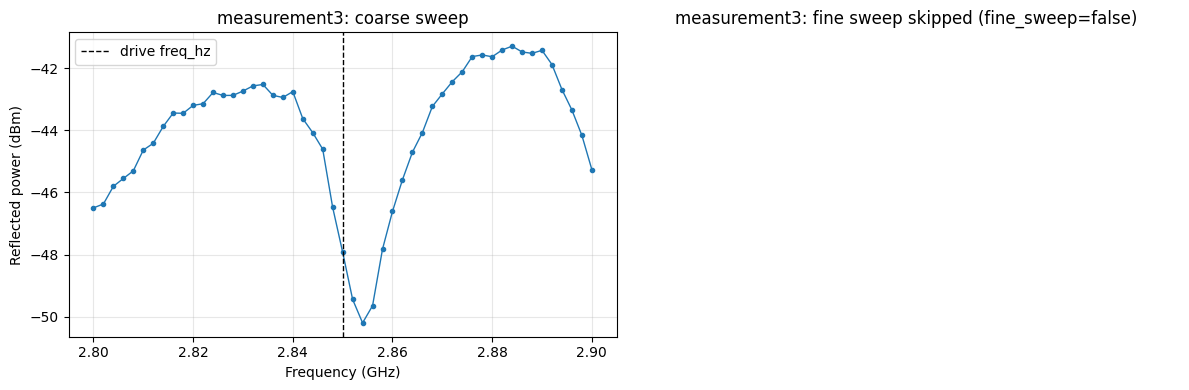

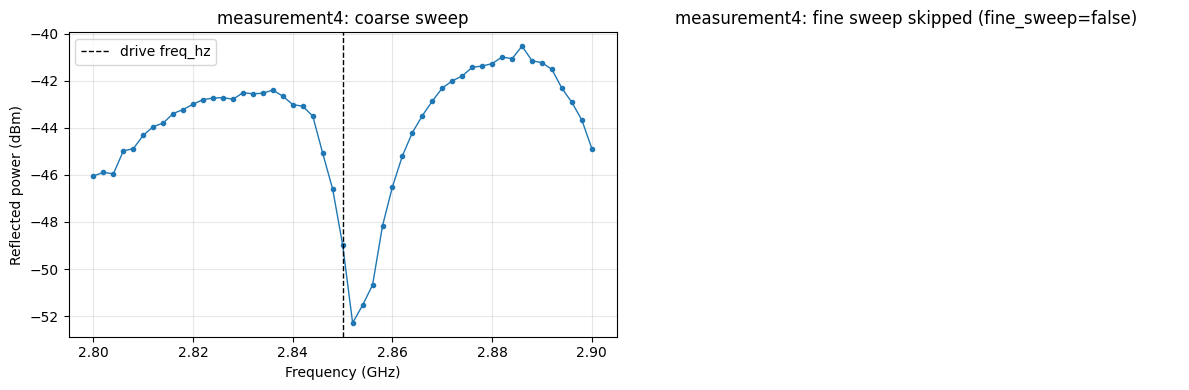

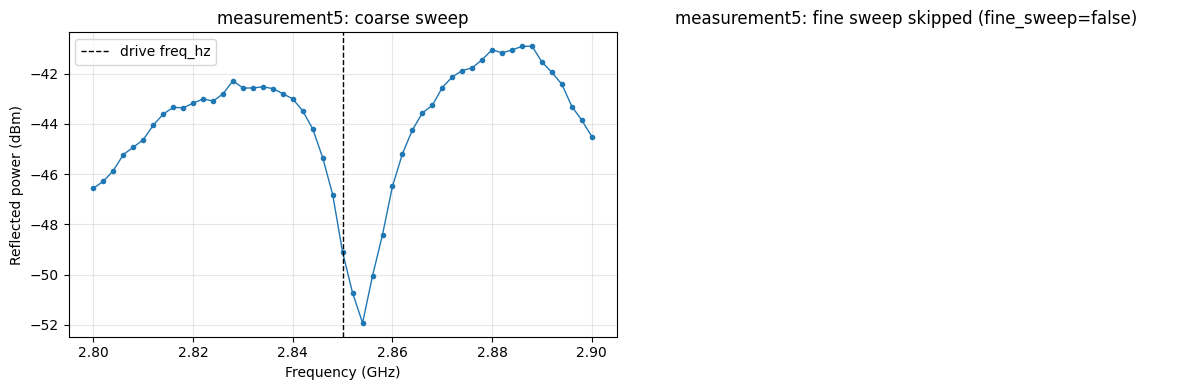

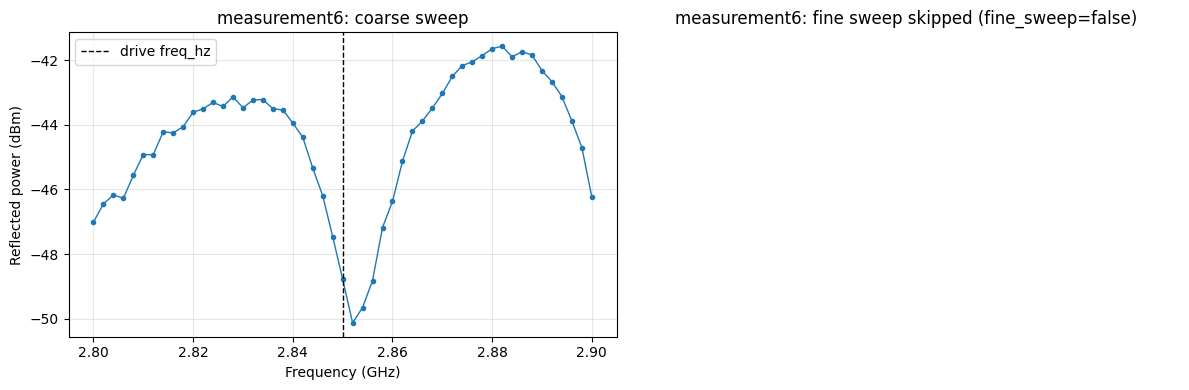

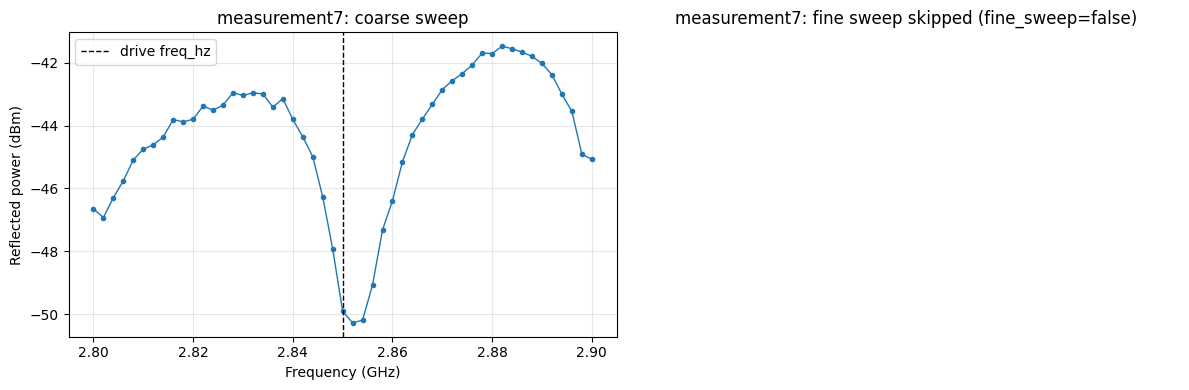

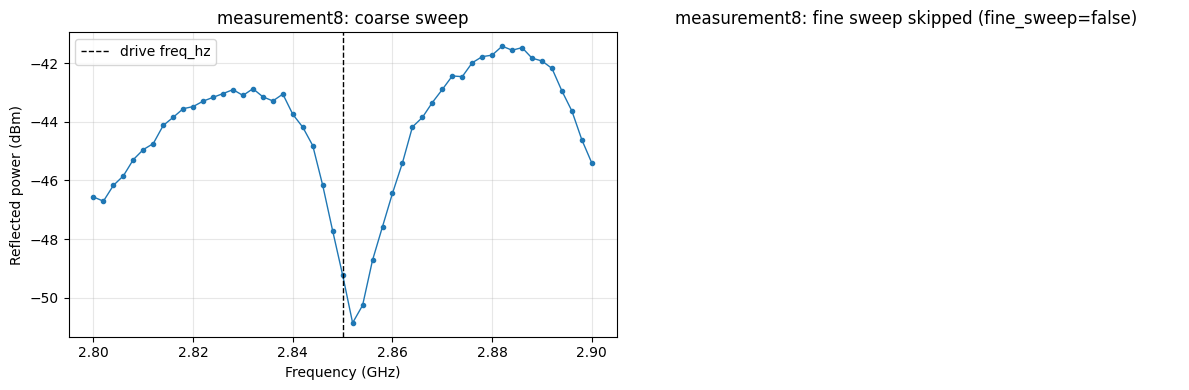

In [4]:
import os

for file_name, d in runs.items():
    coarse_path = f"{d['run_path']}/{file_name}_resonance_coarse.csv"
    fine_path = f"{d['run_path']}/{file_name}_resonance_fine.csv"
    freq_ghz = d["metadata"]["freq_hz"] / 1e9

    if not os.path.exists(coarse_path):
        print(f"{file_name}: no resonance_coarse.csv found "
              "(reflected_power_scan=false, or an older run predating this feature).")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    coarse = np.genfromtxt(coarse_path, delimiter=",", names=True)
    axes[0].plot(coarse["frequency_hz"] / 1e9, coarse["power_dbm"], "o-", ms=3, lw=1)
    axes[0].axvline(freq_ghz, color="k", ls="--", lw=1, label="drive freq_hz")
    axes[0].set_xlabel("Frequency (GHz)")
    axes[0].set_ylabel("Reflected power (dBm)")
    axes[0].set_title(f"{file_name}: coarse sweep")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    if not os.path.exists(fine_path):
        axes[1].set_title(f"{file_name}: fine sweep skipped (fine_sweep=false)")
        axes[1].axis("off")
    else:
        fine = np.genfromtxt(fine_path, delimiter=",", names=True)
        axes[1].plot(fine["frequency_hz"] / 1e9, fine["power_dbm"], "o-", ms=3, lw=1, color="tab:orange")
        axes[1].axvline(freq_ghz, color="k", ls="--", lw=1, label="drive freq_hz")
        axes[1].set_xlabel("Frequency (GHz)")
        axes[1].set_ylabel("Reflected power (dBm)")
        axes[1].set_title(f"{file_name}: fine sweep")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Averaged: measurement5 + measurement6

Elementwise average of X and Y across the two repeats (same `mw_us` grid,
same params), THEN R = sqrt(X^2+Y^2) computed from the averaged X/Y --
never average R directly, since R has a positive noise-rectification bias
that averaging after the fact doesn't remove (see notes.md's
`cw_odmr_lock_in.py` `cmd_sweep_average()` entry for why).

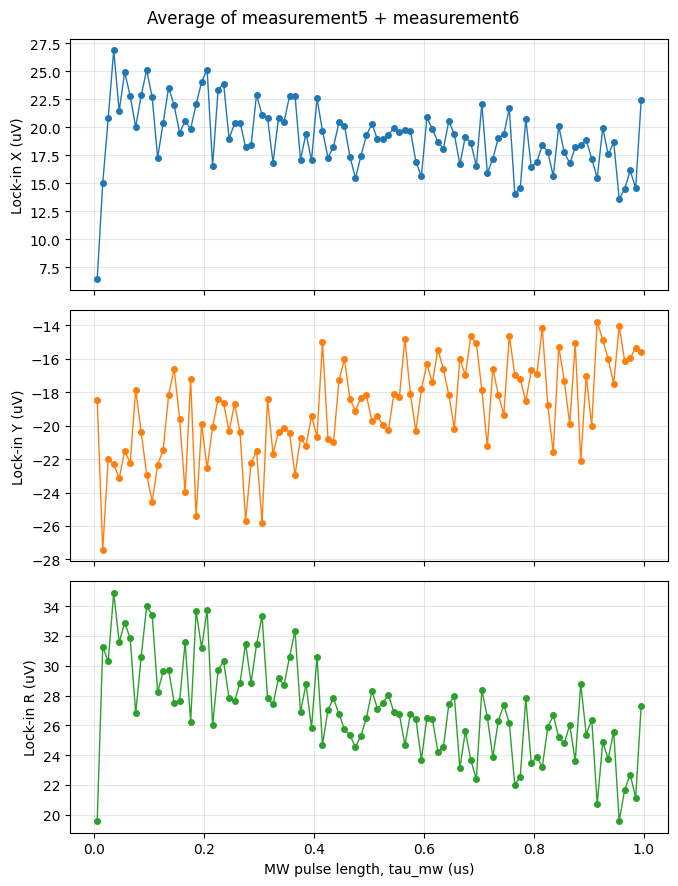

In [5]:
avg_names = ["measurement5", "measurement6"]
d0 = runs[avg_names[0]]
mw_us_avg = d0["mw_us"]
assert all(np.allclose(runs[n]["mw_us"], mw_us_avg) for n in avg_names), \
    "mw_us grids must match exactly to average elementwise"

x_avg = np.mean([runs[n]["x_v"] for n in avg_names], axis=0)
y_avg = np.mean([runs[n]["y_v"] for n in avg_names], axis=0)
r_avg = np.sqrt(x_avg**2 + y_avg**2)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us_avg, x_avg * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us_avg, y_avg * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us_avg, r_avg * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"Average of {' + '.join(avg_names)}")
plt.tight_layout()
plt.show()

## Averaged: measurement_overnight (all completed repeats so far)

`run-repeat` output -- all repeats and the average share one folder
(`D:/rabi/measurement_overnight/`), distinguished by file name. This is
still running, so this cell auto-discovers however many repeats have
FULLY completed (have a `_rabi_x.npy`) rather than assuming a fixed count,
and only includes repeats whose `mw_us` grid exactly matches the first
one (a repeat that tripped partway through, or is still mid-run, is
excluded rather than skewing the average). Re-run this cell later to pick
up more repeats as they finish.

found 13 completed repeats: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  repeat12: mw_us grid mismatch (13 vs 141 points) -- excluded
averaging 12/13 repeats


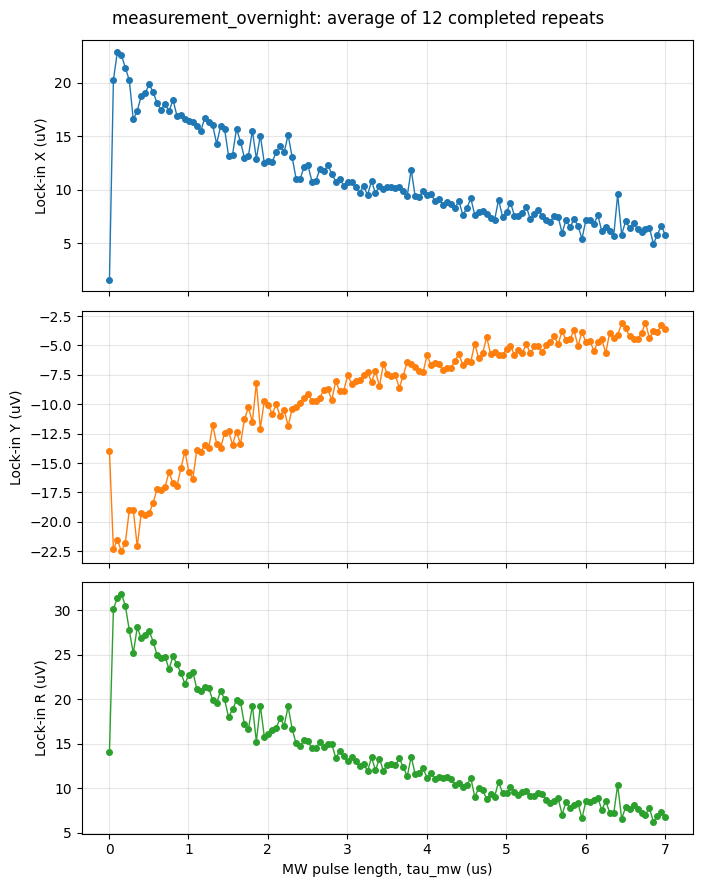

In [6]:
import glob
import re

overnight_name = "measurement_overnight"
overnight_path = f"{DATA_DIR}/{overnight_name}"

repeat_indices = sorted(
    int(re.search(r"_repeat(\d+)_rabi_x\.npy$", p).group(1))
    for p in glob.glob(f"{overnight_path}/{overnight_name}_repeat*_rabi_x.npy")
)
print(f"found {len(repeat_indices)} completed repeats: {repeat_indices}")

mw_us_ref = None
xs, ys = [], []
for i in repeat_indices:
    prefix = f"{overnight_path}/{overnight_name}_repeat{i}"
    mw_us_i = np.load(f"{prefix}_rabi_mw_us.npy")
    if mw_us_ref is None:
        mw_us_ref = mw_us_i
    elif len(mw_us_i) != len(mw_us_ref) or not np.allclose(mw_us_i, mw_us_ref):
        print(f"  repeat{i}: mw_us grid mismatch ({len(mw_us_i)} vs {len(mw_us_ref)} points) -- excluded")
        continue
    xs.append(np.load(f"{prefix}_rabi_x.npy"))
    ys.append(np.load(f"{prefix}_rabi_y.npy"))

print(f"averaging {len(xs)}/{len(repeat_indices)} repeats")

x_avg = np.mean(xs, axis=0)
y_avg = np.mean(ys, axis=0)
r_avg = np.sqrt(x_avg**2 + y_avg**2)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us_ref, x_avg * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us_ref, y_avg * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us_ref, r_avg * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{overnight_name}: average of {len(xs)} completed repeats")
plt.tight_layout()
plt.show()

## Comparison: measurement9 vs measurement9_low_current (averaged)

Both are `run-repeat` batches (5/5 repeats averaged each) -- loads the
already-saved `_avg_rabi_x.npy`/`_avg_rabi_y.npy` directly rather than
re-averaging the individual repeats.

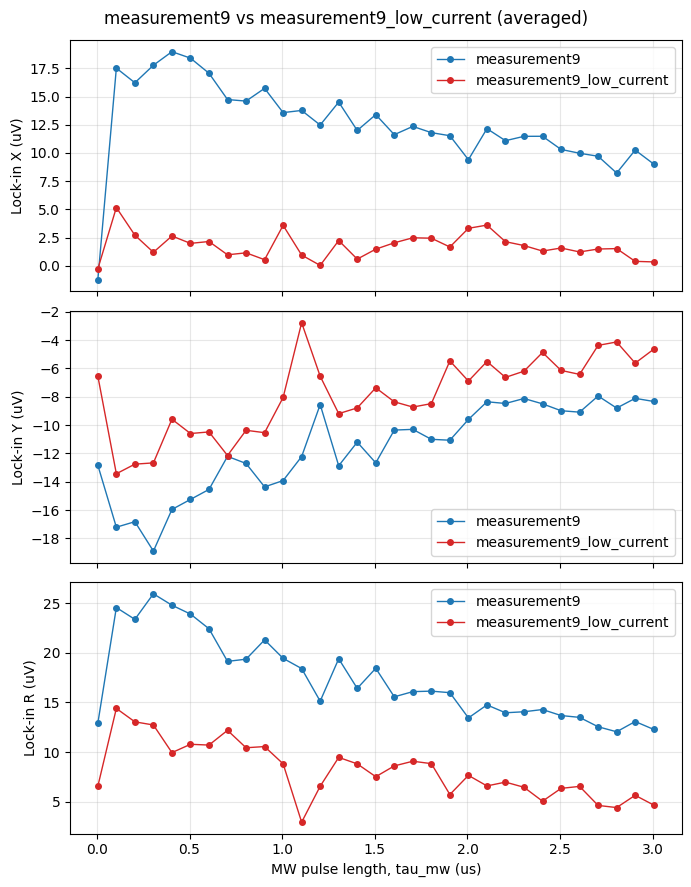

In [7]:
compare_names = ["measurement9", "measurement9_low_current"]
compare_colors = ["tab:blue", "tab:red"]

compare_avg = {}
for name in compare_names:
    run_path = f"{DATA_DIR}/{name}"
    mw_us = np.load(f"{run_path}/{name}_avg_rabi_mw_us.npy")
    x_v = np.load(f"{run_path}/{name}_avg_rabi_x.npy")
    y_v = np.load(f"{run_path}/{name}_avg_rabi_y.npy")
    r_v = np.load(f"{run_path}/{name}_avg_rabi_r.npy")
    compare_avg[name] = dict(mw_us=mw_us, x_v=x_v, y_v=y_v, r_v=r_v)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
for name, color in zip(compare_names, compare_colors):
    d = compare_avg[name]
    axes[0].plot(d["mw_us"], d["x_v"] * 1e6, "o-", ms=4, lw=1, color=color, label=name)
    axes[1].plot(d["mw_us"], d["y_v"] * 1e6, "o-", ms=4, lw=1, color=color, label=name)
    axes[2].plot(d["mw_us"], d["r_v"] * 1e6, "o-", ms=4, lw=1, color=color, label=name)

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("measurement9 vs measurement9_low_current (averaged)")
plt.tight_layout()
plt.show()

## Combined average: measurement10 + measurement11

Pools ALL valid repeats from BOTH `measurement10` and `measurement11`
(same params: 2.842 GHz, n_reps=250, sensitivity 1e-4, same `mw_us` grid)
into ONE elementwise average -- not a side-by-side comparison.
`measurement10_repeat1` (shorter `mw_us` grid, partial/tripped) is
excluded, same as before; `measurement10_repeat0` and all of
`measurement11`'s 4 repeats are included.

  measurement10 repeat1: mw_us grid mismatch (5 vs 20 points) -- excluded
measurement10: including 1 repeat(s)
measurement11: including 4 repeat(s)
pooling 5 repeats total across ['measurement10', 'measurement11']


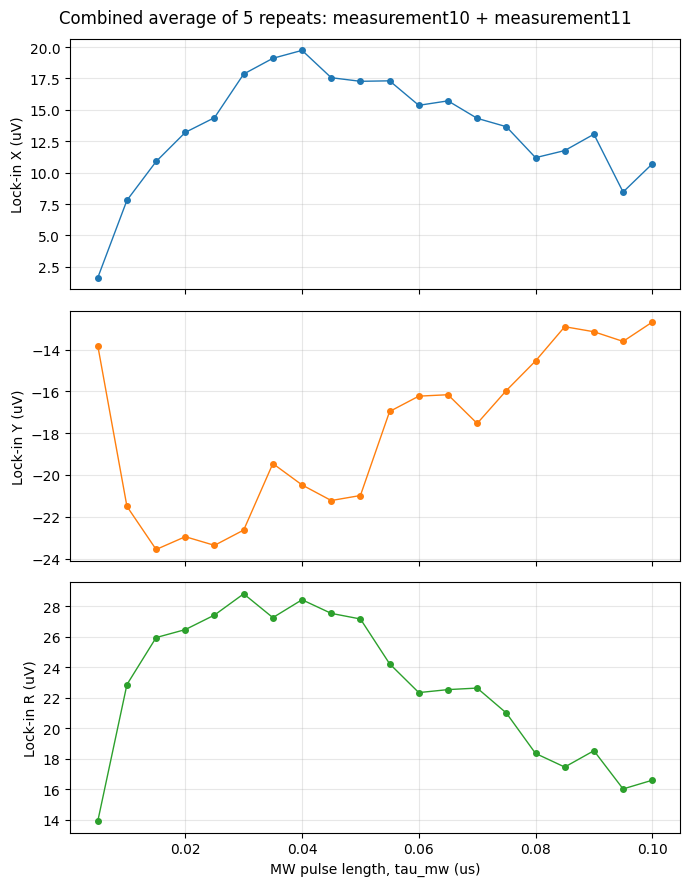

In [8]:
import glob
import re

def collect_repeats(name):
    """Auto-discover <name>_repeat{i}_rabi_x.npy files, returning
    (mw_us_ref, [x arrays], [y arrays]) for whichever repeats match the
    first repeat's mw_us grid exactly (partial/tripped repeats with a
    shorter grid are dropped)."""
    run_path = f"{DATA_DIR}/{name}"
    indices = sorted(
        int(re.search(r"_repeat(\d+)_rabi_x\.npy$", p).group(1))
        for p in glob.glob(f"{run_path}/{name}_repeat*_rabi_x.npy")
    )
    mw_us_ref = None
    xs, ys = [], []
    for i in indices:
        prefix = f"{run_path}/{name}_repeat{i}"
        mw_us_i = np.load(f"{prefix}_rabi_mw_us.npy")
        if mw_us_ref is None:
            mw_us_ref = mw_us_i
        elif len(mw_us_i) != len(mw_us_ref) or not np.allclose(mw_us_i, mw_us_ref):
            print(f"  {name} repeat{i}: mw_us grid mismatch "
                  f"({len(mw_us_i)} vs {len(mw_us_ref)} points) -- excluded")
            continue
        xs.append(np.load(f"{prefix}_rabi_x.npy"))
        ys.append(np.load(f"{prefix}_rabi_y.npy"))
    return mw_us_ref, xs, ys


pool_names = ["measurement10", "measurement11"]

mw_us_combined = None
all_xs, all_ys = [], []
for name in pool_names:
    mw_us_i, xs, ys = collect_repeats(name)
    if mw_us_combined is None:
        mw_us_combined = mw_us_i
    elif len(mw_us_i) != len(mw_us_combined) or not np.allclose(mw_us_i, mw_us_combined):
        raise ValueError(f"{name}'s mw_us grid doesn't match -- can't pool "
                          f"into one average")
    all_xs.extend(xs)
    all_ys.extend(ys)
    print(f"{name}: including {len(xs)} repeat(s)")

print(f"pooling {len(all_xs)} repeats total across {pool_names}")

x_avg = np.mean(all_xs, axis=0)
y_avg = np.mean(all_ys, axis=0)
r_avg = np.sqrt(x_avg**2 + y_avg**2)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us_combined, x_avg * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us_combined, y_avg * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us_combined, r_avg * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"Combined average of {len(all_xs)} repeats: {' + '.join(pool_names)}")
plt.tight_layout()
plt.show()

## Averaged: measurement13

`run-repeat` batch, 5/5 repeats averaged (2.842 GHz, n_reps=250,
coil_current_a=2.0). Loads the already-saved `_avg_rabi_*.npy` directly.

measurement13: 50 points, tau_mw 0.005-0.250 us
freq_hz=2842000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
coil_current_a=2.0



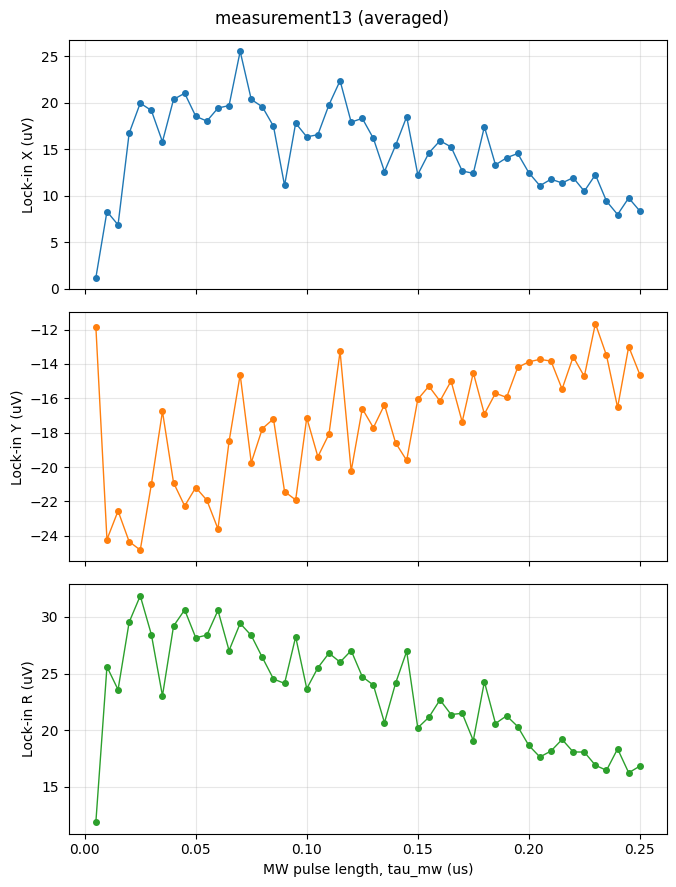

In [9]:
name13 = "measurement13"
run_path13 = f"{DATA_DIR}/{name13}"
mw_us13 = np.load(f"{run_path13}/{name13}_avg_rabi_mw_us.npy")
x13 = np.load(f"{run_path13}/{name13}_avg_rabi_x.npy")
y13 = np.load(f"{run_path13}/{name13}_avg_rabi_y.npy")
r13 = np.load(f"{run_path13}/{name13}_avg_rabi_r.npy")

with open(f"{run_path13}/{name13}_repeat0_rabi_metadata.txt") as fh:
    metadata_text13 = fh.read()
print(f"{name13}: {len(mw_us13)} points, tau_mw {mw_us13.min():.3f}-{mw_us13.max():.3f} us")
print(metadata_text13)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us13, x13 * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us13, y13 * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us13, r13 * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name13} (averaged)")
plt.tight_layout()
plt.show()

## Averaged: measurement14 (use_resonance_freq + coil current scan)

First real-hardware run of `use_resonance_freq=true`, which also triggers
the coil-current optimization scan (see notes.md). Resolved
`freq_hz=2839.85` MHz, picked `coil_current_a=2.6` A. 5/5 repeats
averaged. Plots the main Rabi result plus the coil-scan curve
(`repeat0`'s scan -- only the first repeat actually runs it, per
`cmd_run_repeat()`'s design).

measurement14: 21 points, tau_mw 0.005-1.005 us
freq_hz=2840200000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
coil_current_a=2.300000000000001



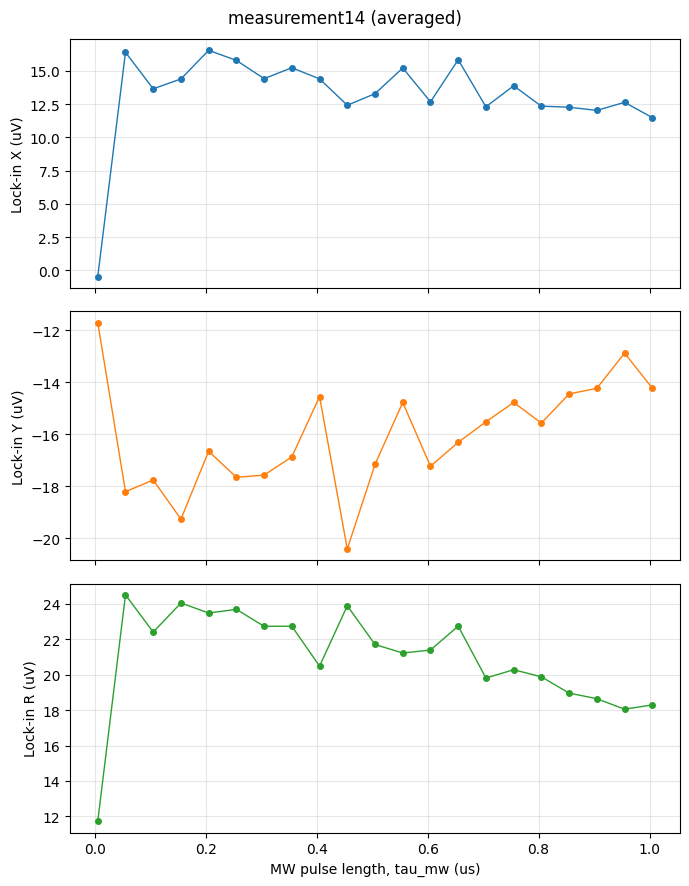

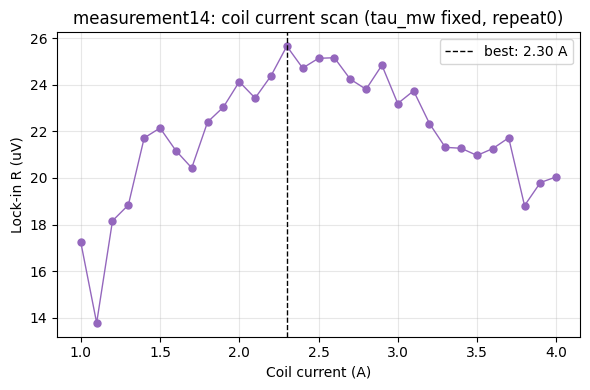

In [10]:
name14 = "measurement14"
run_path14 = f"{DATA_DIR}/{name14}"
mw_us14 = np.load(f"{run_path14}/{name14}_avg_rabi_mw_us.npy")
x14 = np.load(f"{run_path14}/{name14}_avg_rabi_x.npy")
y14 = np.load(f"{run_path14}/{name14}_avg_rabi_y.npy")
r14 = np.load(f"{run_path14}/{name14}_avg_rabi_r.npy")

with open(f"{run_path14}/{name14}_repeat0_rabi_metadata.txt") as fh:
    metadata_text14 = fh.read()
print(f"{name14}: {len(mw_us14)} points, tau_mw {mw_us14.min():.3f}-{mw_us14.max():.3f} us")
print(metadata_text14)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us14, x14 * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us14, y14 * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us14, r14 * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name14} (averaged)")
plt.tight_layout()
plt.show()

# Coil current scan (repeat0 only)
coil_currents14 = np.load(f"{run_path14}/{name14}_repeat0_coil_scan_current_a.npy")
coil_r14 = np.load(f"{run_path14}/{name14}_repeat0_coil_scan_r.npy")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(coil_currents14, coil_r14 * 1e6, "o-", ms=5, lw=1, color="tab:purple")
best_idx14 = np.argmax(coil_r14)
ax.axvline(coil_currents14[best_idx14], color="k", ls="--", lw=1,
           label=f"best: {coil_currents14[best_idx14]:.2f} A")
ax.set_xlabel("Coil current (A)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name14}: coil current scan (tau_mw fixed, repeat0)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Post-hoc X/Y phase calibration

`rabi.py` never auto-calibrates the SR830's phase (`phase_deg` is applied
as-is, whatever was passed in) -- this rotates already-collected X/Y data
by ONE fixed angle, chosen from the data itself, instead of having to
redo the measurement with a re-calibrated `phase_deg`. Same idea as
nulling Y on a real lock-in, but computed from the WHOLE sweep's
variation at once rather than a single live reading, and applied
uniformly (one angle for the whole dataset, not per point).

Method: mean-subtract X/Y (so a constant offset doesn't bias the angle
choice, only the tau_mw-dependent signal does), then find the rotation
angle that maximizes the ROTATED X's variance -- equivalent to finding
the principal axis of the (X, Y) scatter (PCA in 2D). That angle is
`0.5 * arctan2(2*Cov(X,Y), Var(X)-Var(Y))`, with a second candidate 90
degrees away (the two principal axes) -- picks whichever of the two
actually maximizes the rotated X's variance, so the real Rabi signal
lands in X and Y becomes flat residual noise. Applied to the ORIGINAL
(non-mean-subtracted) X/Y, so the rotated output is still the real
demodulated value at each point, just phase-corrected.

measurement14: post-hoc phase correction = -23.31 deg
  Y std before: 2.063 uV, after: 1.607 uV (should be smaller -- signal moved out of Y)


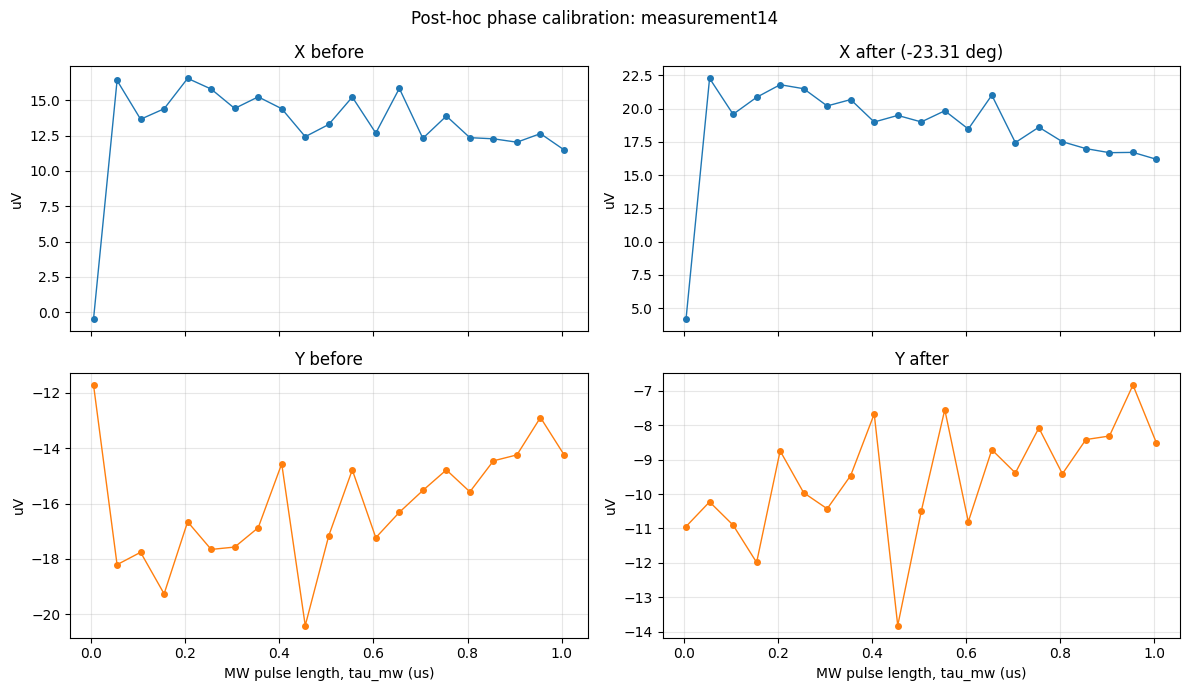

In [11]:
def calibrate_phase_post_hoc(x, y):
    """Find ONE rotation angle (degrees) that maximizes the rotated X's
    variance across the whole (x, y) dataset, and return
    (x_rotated, y_rotated, theta_deg). x, y: 1D arrays, same length,
    one value per sweep point (e.g. per tau_mw).

    x_rotated/y_rotated are the SAME shape as x/y -- apply once, use
    everywhere downstream (plots, fits) in place of the raw x/y.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x0 = x - x.mean()
    y0 = y - y.mean()
    var_x, var_y = np.var(x0), np.var(y0)
    cov_xy = np.mean(x0 * y0)

    # Principal-axis angle of the (x0, y0) scatter -- two candidates 90
    # degrees apart (the two principal axes); pick whichever maximizes
    # the rotated X's variance, so signal lands in X and Y is left flat.
    theta_candidates = [
        0.5 * np.arctan2(2 * cov_xy, var_x - var_y),
    ]
    theta_candidates.append(theta_candidates[0] + np.pi / 2)

    def rotate(theta):
        c, s = np.cos(theta), np.sin(theta)
        return x * c + y * s, -x * s + y * c

    best_theta, best_var = None, -np.inf
    for theta in theta_candidates:
        x_rot, _ = rotate(theta)
        v = np.var(x_rot - x_rot.mean())
        if v > best_var:
            best_theta, best_var = theta, v

    x_rotated, y_rotated = rotate(best_theta)
    return x_rotated, y_rotated, np.degrees(best_theta)


# Demonstration: measurement14's averaged data, before/after
x_before = x14
y_before = y14
x_after, y_after, theta_deg = calibrate_phase_post_hoc(x_before, y_before)
print(f"measurement14: post-hoc phase correction = {theta_deg:.2f} deg")
print(f"  Y std before: {y_before.std()*1e6:.3f} uV, after: {y_after.std()*1e6:.3f} uV "
      f"(should be smaller -- signal moved out of Y)")

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes[0, 0].plot(mw_us14, x_before * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[0, 0].set_title("X before")
axes[1, 0].plot(mw_us14, y_before * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[1, 0].set_title("Y before")
axes[0, 1].plot(mw_us14, x_after * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[0, 1].set_title(f"X after ({theta_deg:.2f} deg)")
axes[1, 1].plot(mw_us14, y_after * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[1, 1].set_title("Y after")
for ax in axes.flat:
    ax.set_ylabel("uV")
    ax.grid(alpha=0.3)
axes[1, 0].set_xlabel("MW pulse length, tau_mw (us)")
axes[1, 1].set_xlabel("MW pulse length, tau_mw (us)")
fig.suptitle("Post-hoc phase calibration: measurement14")
plt.tight_layout()
plt.show()

## Averaged: measurement15 (use_resonance_freq + coil current scan)

`run-repeat`, 5/5 repeats averaged. Resolved `freq_hz=2840.0` MHz, picked
`coil_current_a=2.4` A. `constant_shot_period=false`, `laser_us=5.0`
(longer than the other runs above).

measurement15: 21 points, tau_mw 0.005-1.005 us
freq_hz=2840000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
coil_current_a=2.4000000000000012
constant_shot_period=0
pad_min_us=0.0



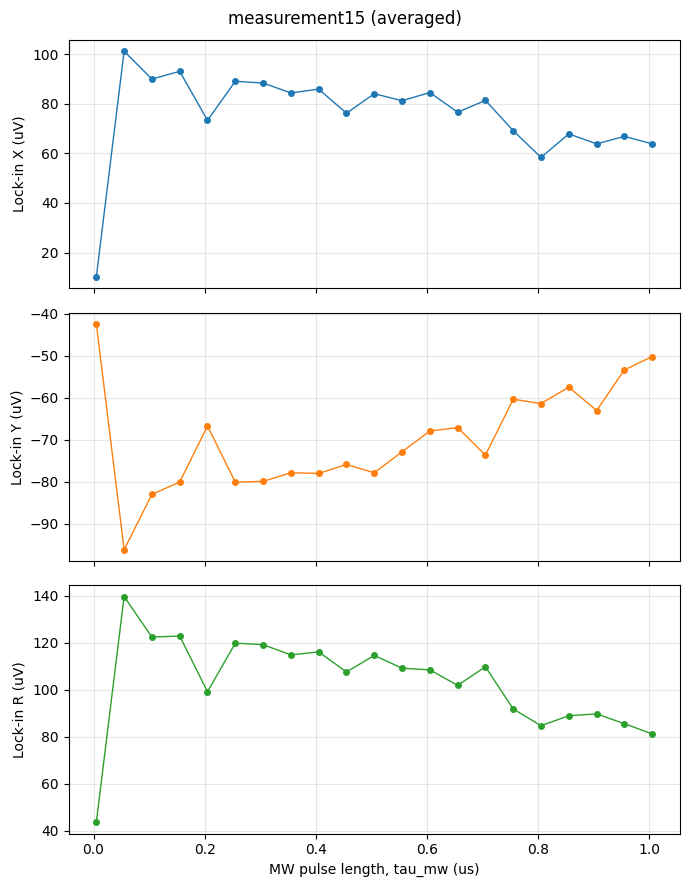

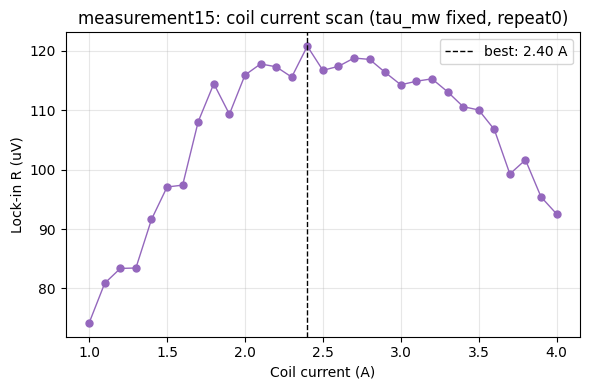

In [12]:
name15 = "measurement15"
run_path15 = f"{DATA_DIR}/{name15}"
mw_us15 = np.load(f"{run_path15}/{name15}_avg_rabi_mw_us.npy")
x15 = np.load(f"{run_path15}/{name15}_avg_rabi_x.npy")
y15 = np.load(f"{run_path15}/{name15}_avg_rabi_y.npy")
r15 = np.load(f"{run_path15}/{name15}_avg_rabi_r.npy")

with open(f"{run_path15}/{name15}_repeat0_rabi_metadata.txt") as fh:
    metadata_text15 = fh.read()
print(f"{name15}: {len(mw_us15)} points, tau_mw {mw_us15.min():.3f}-{mw_us15.max():.3f} us")
print(metadata_text15)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us15, x15 * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us15, y15 * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us15, r15 * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name15} (averaged)")
plt.tight_layout()
plt.show()

# Coil current scan (repeat0 only)
coil_currents15 = np.load(f"{run_path15}/{name15}_repeat0_coil_scan_current_a.npy")
coil_r15 = np.load(f"{run_path15}/{name15}_repeat0_coil_scan_r.npy")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(coil_currents15, coil_r15 * 1e6, "o-", ms=5, lw=1, color="tab:purple")
best_idx15 = np.argmax(coil_r15)
ax.axvline(coil_currents15[best_idx15], color="k", ls="--", lw=1,
           label=f"best: {coil_currents15[best_idx15]:.2f} A")
ax.set_xlabel("Coil current (A)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name15}: coil current scan (tau_mw fixed, repeat0)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Averaged: measurement16 (use_resonance_freq + coil scan + constant_shot_period)

`run-repeat`, 5/5 repeats averaged. Resolved `freq_hz=2800.5` MHz, picked
`coil_current_a=3.9` A. First real-hardware run with
`constant_shot_period=1` (`pad_min_us=0.1`) -- the total rep period
(and therefore laser duty cycle/true reference frequency) should now be
identical at every point across this sweep.

measurement16: 21 points, tau_mw 0.005-1.005 us
freq_hz=2800500000.0
drive_power_dbm=0.0
n_reps=250
laser_us=5.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0
coil_current_a=3.9000000000000026
constant_shot_period=1
pad_min_us=0.1



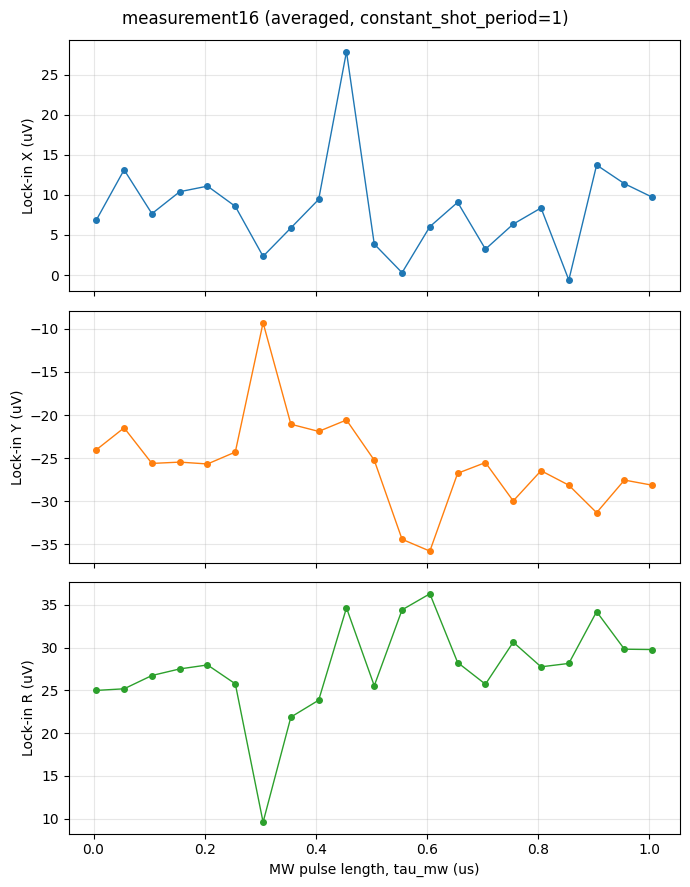

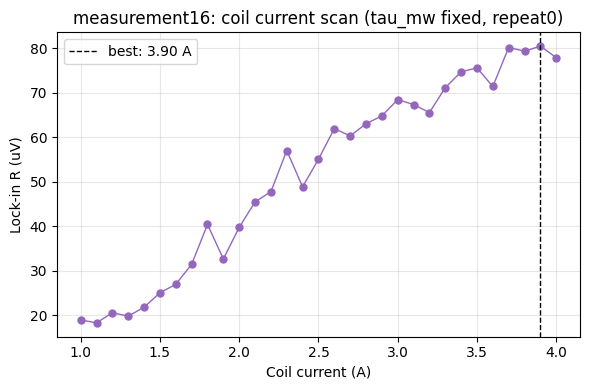

In [13]:
name16 = "measurement16"
run_path16 = f"{DATA_DIR}/{name16}"
mw_us16 = np.load(f"{run_path16}/{name16}_avg_rabi_mw_us.npy")
x16 = np.load(f"{run_path16}/{name16}_avg_rabi_x.npy")
y16 = np.load(f"{run_path16}/{name16}_avg_rabi_y.npy")
r16 = np.load(f"{run_path16}/{name16}_avg_rabi_r.npy")

with open(f"{run_path16}/{name16}_repeat0_rabi_metadata.txt") as fh:
    metadata_text16 = fh.read()
print(f"{name16}: {len(mw_us16)} points, tau_mw {mw_us16.min():.3f}-{mw_us16.max():.3f} us")
print(metadata_text16)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us16, x16 * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us16, y16 * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us16, r16 * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name16} (averaged, constant_shot_period=1)")
plt.tight_layout()
plt.show()

# Coil current scan (repeat0 only)
coil_currents16 = np.load(f"{run_path16}/{name16}_repeat0_coil_scan_current_a.npy")
coil_r16 = np.load(f"{run_path16}/{name16}_repeat0_coil_scan_r.npy")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(coil_currents16, coil_r16 * 1e6, "o-", ms=5, lw=1, color="tab:purple")
best_idx16 = np.argmax(coil_r16)
ax.axvline(coil_currents16[best_idx16], color="k", ls="--", lw=1,
           label=f"best: {coil_currents16[best_idx16]:.2f} A")
ax.set_xlabel("Coil current (A)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name16}: coil current scan (tau_mw fixed, repeat0)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()